# Final Submitted Model Feature Importance

This notebook analyzes the feature importance of the submitted final model, i.e. the model-development LOO result reported as R2 = 0.781, PearsonR = 0.886, and MAE = 0.161 kcal/mol. It does not use nested-validation results.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from rdkit.Chem import Descriptors
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

def find_project_dir():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / 'desc' / 'final_descriptor_map.npy').exists() and (path / 'rxnpredict').exists():
            return path
    raise FileNotFoundError('Could not locate FerroEnantioML project root.')

PROJECT_DIR = find_project_dir()
SCRIPTS_DIR = PROJECT_DIR / 'scripts'
RESULTS_DIR = SCRIPTS_DIR / 'results'
FIGURES_DIR = RESULTS_DIR / 'final_model_feature_importance_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from rxnpredict.evaluate.eval import get_val_score_add_data
from rxnpredict.ts.desc import sel_satisfy_ts_data, vec_ts_pair_in_dataset, get_diff_ts_desc

print('Python:', sys.executable)
print('Project:', PROJECT_DIR)

Python: /bin/python3
Project: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML


In [2]:

def process_desc_local(array, return_idx=False):
    array = np.array(array, dtype=np.float32)
    keep = []
    for idx in range(array.shape[1]):
        desc_range = array[:, idx].max() - array[:, idx].min()
        if desc_range != 0 and not np.isnan(desc_range) and not np.isinf(desc_range):
            keep.append(idx)
    out = array[:, keep]
    return (out, keep) if return_idx else out


def maxminscale_local(array, return_scale=False):
    max_val = array.max(axis=0)
    min_val = array.min(axis=0)
    scaled = (array - min_val) / (max_val - min_val)
    return (scaled, max_val, min_val) if return_scale else scaled


def sel_high_corr_desc_local(desc, target, threshold=0.15, return_idx=False):
    selected = []
    for idx in range(desc.shape[1]):
        corr = pearsonr(desc[:, idx], target)[0]
        if abs(corr) > threshold:
            selected.append(idx)
    if not selected:
        selected = list(range(desc.shape[1]))
    out = desc[:, selected]
    return (out, selected) if return_idx else out


def reduce_desc_with_corr_matrix_local(desc, threshold=0.9, ret_idx=False):
    corr_matrix = pd.DataFrame(desc).corr()
    keep = []
    considered = set()
    for idx in range(corr_matrix.shape[0]):
        if idx not in considered:
            highly_correlated = corr_matrix.index[
                (corr_matrix.iloc[:, idx].abs() > threshold) & (corr_matrix.index != idx)
            ]
            considered.update(highly_correlated)
            considered.add(idx)
            keep.append(idx)
    out = desc[:, keep]
    return (out, keep) if ret_idx else out


def reconstruct_final_feature_names():
    desc_name = 'SPOC'
    descriptor_pearsonr_threshold = 0.95
    descriptor_target_pearsonr_threshold = 0.2
    base_rct_keys = ['Reactant1', 'Reactant2']
    target_rct_keys = ['Reactant1', 'Reactant2']
    base_sol_keys = ['Solvents']
    target_sol_keys = ['Solvents']
    base_rgt_keys = ['Reagents']
    target_rgt_keys = ['Reagents']
    base_ts_key = ['Reactant2', 'Reagent5']
    target_ts_key = ['Reactant2', 'Reagent2']

    base_data = pd.read_csv(PROJECT_DIR / 'data' / 'base_data.csv').dropna(axis=1, how='all')
    target_data = pd.read_csv(PROJECT_DIR / 'data' / 'target_data.csv').dropna(axis=1, how='all')
    for key in target_rct_keys + target_sol_keys + target_rgt_keys:
        target_data[key] = target_data[key].fillna('')
    for key in base_rct_keys + base_sol_keys + base_rgt_keys:
        base_data[key] = base_data[key].fillna('')
    target_data = target_data.dropna(subset=target_rct_keys + target_ts_key)
    base_data = base_data.dropna(subset=base_rct_keys + base_ts_key)

    clear_smiles_tsdesc_map = np.load(PROJECT_DIR / 'desc' / 'clear_smiles_tsdesc_map.npy', allow_pickle=True).item()
    sel_target_data = target_data.iloc[sel_satisfy_ts_data(target_data, target_ts_key, clear_smiles_tsdesc_map)]
    sel_base_data = base_data.iloc[sel_satisfy_ts_data(base_data, base_ts_key, clear_smiles_tsdesc_map)]

    target_ts_desc_inf = vec_ts_pair_in_dataset(sel_target_data, target_ts_key, clear_smiles_tsdesc_map)
    target_ts_desc = target_ts_desc_inf[:, 0, :].astype(np.float32)
    target_ts_desc_names = target_ts_desc_inf[:, 1, :]
    base_ts_desc_inf = vec_ts_pair_in_dataset(sel_base_data, base_ts_key, clear_smiles_tsdesc_map)
    base_ts_desc = base_ts_desc_inf[:, 0, :].astype(np.float32)
    base_ts_desc_names = base_ts_desc_inf[:, 1, :]

    target_ts_diff_desc, target_ts_diff_desc_names = get_diff_ts_desc(target_ts_desc, target_ts_desc_names[0])
    base_ts_diff_desc, _ = get_diff_ts_desc(base_ts_desc, base_ts_desc_names[0])
    target_ts_desc = np.concatenate([target_ts_desc, target_ts_diff_desc], axis=1)
    base_ts_desc = np.concatenate([base_ts_desc, base_ts_diff_desc], axis=1)
    target_ts_desc_names = np.concatenate([target_ts_desc_names[0], target_ts_diff_desc_names], axis=0)

    target_ddG = sel_target_data['ddG'].to_numpy()
    base_ddG = sel_base_data['ddG'].to_numpy()
    y_all = np.concatenate([target_ddG, base_ddG])

    concat_ts_desc, ts_process_idx = process_desc_local(
        np.concatenate([target_ts_desc, base_ts_desc], axis=0), return_idx=True
    )
    concat_ts_desc, _, _ = maxminscale_local(concat_ts_desc, return_scale=True)
    concat_ts_desc, ts_high_tgt_corr_idx = sel_high_corr_desc_local(
        concat_ts_desc, y_all, threshold=descriptor_target_pearsonr_threshold, return_idx=True
    )
    concat_ts_desc, ts_high_corr_idx = reduce_desc_with_corr_matrix_local(
        concat_ts_desc, threshold=descriptor_pearsonr_threshold, ret_idx=True
    )
    target_ts_desc_filtered = concat_ts_desc[:target_ts_desc.shape[0]]
    base_ts_desc_filtered = concat_ts_desc[target_ts_desc.shape[0]:]
    ts_names_filtered = target_ts_desc_names[ts_process_idx][ts_high_tgt_corr_idx][ts_high_corr_idx]

    pregen_desc_map = np.load(PROJECT_DIR / 'desc' / 'desc_for_other_components.npy', allow_pickle=True).item()
    target_merg_rxn_desc = pregen_desc_map[desc_name]['target']
    base_merg_rxn_desc = pregen_desc_map[desc_name]['base']

    rdkit_desc_names = np.array([name for name, _ in Descriptors._descList])
    one_component_len = target_merg_rxn_desc.shape[1] // 4
    # The SPOC implementation concatenates RDKit descriptors first, then Morgan fingerprint bits.
    spoc_component_names = np.concatenate([
        rdkit_desc_names,
        np.array([f'MF_{idx}' for idx in range(one_component_len - len(rdkit_desc_names))]),
    ])
    merg_desc_names = np.concatenate([
        [f'Reactant1 SPOC {name}' for name in spoc_component_names],
        [f'Reactant2 SPOC {name}' for name in spoc_component_names],
        [f'Solvent SPOC {name}' for name in spoc_component_names],
        [f'Reagent SPOC {name}' for name in spoc_component_names],
    ])

    concat_merg_desc, merg_process_idx = process_desc_local(
        np.concatenate([target_merg_rxn_desc, base_merg_rxn_desc], axis=0), return_idx=True
    )
    concat_merg_desc, _, _ = maxminscale_local(concat_merg_desc, return_scale=True)
    concat_merg_desc, merg_high_tgt_corr_idx = sel_high_corr_desc_local(
        concat_merg_desc, y_all, threshold=descriptor_target_pearsonr_threshold, return_idx=True
    )
    concat_merg_desc, merg_high_corr_idx = reduce_desc_with_corr_matrix_local(
        concat_merg_desc, threshold=descriptor_pearsonr_threshold, ret_idx=True
    )
    target_merg_desc_filtered = concat_merg_desc[:target_merg_rxn_desc.shape[0]]
    base_merg_desc_filtered = concat_merg_desc[target_merg_rxn_desc.shape[0]:]
    merg_names_filtered = merg_desc_names[merg_process_idx][merg_high_tgt_corr_idx][merg_high_corr_idx]

    target_full_desc = np.concatenate([target_merg_desc_filtered, target_ts_desc_filtered], axis=1)
    base_full_desc = np.concatenate([base_merg_desc_filtered, base_ts_desc_filtered], axis=1)
    full_desc, full_process_idx = process_desc_local(
        np.concatenate([target_full_desc, base_full_desc], axis=0), return_idx=True
    )
    full_desc, _, _ = maxminscale_local(full_desc, return_scale=True)
    reconstructed_target_X = full_desc[:target_full_desc.shape[0]]
    reconstructed_base_X = full_desc[target_full_desc.shape[0]:]
    final_feature_names = np.concatenate([merg_names_filtered, ts_names_filtered])[full_process_idx]
    final_feature_source = np.concatenate([
        np.repeat('SPOC', len(merg_names_filtered)),
        np.repeat('TS', len(ts_names_filtered)),
    ])[full_process_idx]

    final_desc_map = np.load(PROJECT_DIR / 'desc' / 'final_descriptor_map.npy', allow_pickle=True).item()['SPOC']
    checks = pd.DataFrame([
        {
            'n_spoc_after_filtering': int(len(merg_names_filtered)),
            'n_ts_after_filtering': int(len(ts_names_filtered)),
            'n_final_features': int(len(final_feature_names)),
            'base_X_matches_final_descriptor_map': bool(np.allclose(reconstructed_base_X, final_desc_map['base_X'])),
            'target_X_matches_final_descriptor_map': bool(np.allclose(reconstructed_target_X, final_desc_map['target_X'])),
        }
    ])
    return final_feature_names, final_feature_source, checks


In [3]:
RANDOM_STATE = 1024
TOPK = 300
MERGE_METHOD = 'delta'
DIST_TYPE = 'euclidean'
SELECTION_INF = {'type': 'loo', 'fold': 10, 'metric': ['r2', 'mae']}

MODEL_PARAMS = {
    'n_estimators': 117,
    'min_samples_split': 5,
    'max_depth': 3,
}

DESC_PATH = PROJECT_DIR / 'desc' / 'final_descriptor_map.npy'
DROP_FILES = sorted(RESULTS_DIR.glob('dropped_feat_idx_0.7813588887800107.npy'))
if not DROP_FILES:
    DROP_FILES = sorted(RESULTS_DIR.glob('dropped_feat_idx_*.npy'))
if not DROP_FILES:
    raise FileNotFoundError('No dropped_feat_idx_*.npy file found in scripts/results.')
DROP_PATH = DROP_FILES[-1]

desc_map = np.load(DESC_PATH, allow_pickle=True).item()['SPOC']
base_X = np.asarray(desc_map['base_X'])
base_y = np.asarray(desc_map['base_y'])
target_X = np.asarray(desc_map['target_X'])
target_y = np.asarray(desc_map['target_y'])

dropped_feature_indices = np.load(DROP_PATH, allow_pickle=True).astype(int).tolist()
selected_feature_indices = [idx for idx in range(base_X.shape[1]) if idx not in dropped_feature_indices]
feature_names, feature_sources, feature_name_checks = reconstruct_final_feature_names()
display(feature_name_checks)
assert len(feature_names) == base_X.shape[1]
assert feature_name_checks['base_X_matches_final_descriptor_map'].iloc[0]
assert feature_name_checks['target_X_matches_final_descriptor_map'].iloc[0]

print('Descriptor path:', DESC_PATH)
print('Dropped feature path:', DROP_PATH)
print('base_X:', base_X.shape, 'target_X:', target_X.shape)
print('Dropped features:', dropped_feature_indices)
print('Selected features:', len(selected_feature_indices))

/tmp/ipykernel_1511236/2544964083.py:2: RuntimeWarning: overflow encountered in cast
  array = np.array(array, dtype=np.float32)


,n_spoc_after_filtering,n_ts_after_filtering,n_final_features,base_X_matches_final_descriptor_map,target_X_matches_final_descriptor_map
0,193,67,260,True,True


Descriptor path: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/desc/final_descriptor_map.npy
Dropped feature path: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/scripts/results/dropped_feat_idx_0.7813588887800107.npy
base_X: (446, 260) target_X: (55, 260)
Dropped features: [0, 53, 1, 42, 5, 2, 21, 172]
Selected features: 252


## Reproduce the Submitted LOO Model

The reported model uses the 252 remaining features after GBFE. Feature importance is collected from the base and delta Gradient Boosting models fitted inside each LOO split.

In [4]:
model = GradientBoostingRegressor(**MODEL_PARAMS, random_state=RANDOM_STATE)

va_Y, va_P, score_map, base_importances, delta_importances = get_val_score_add_data(
    model,
    base_X[:, selected_feature_indices],
    base_y,
    target_X[:, selected_feature_indices],
    target_y,
    selection_inf=SELECTION_INF,
    merge_method=MERGE_METHOD,
    topk=TOPK,
    dist_type=DIST_TYPE,
    verbose=False,
    ret_feat_importance=True,
)

pearson_r = pearsonr(va_Y, va_P)[0]
mae = mean_absolute_error(va_Y, va_P)
r2 = r2_score(va_Y, va_P)

metrics_df = pd.DataFrame([
    {'R2': r2, 'PearsonR': pearson_r, 'MAE_kcal_mol': mae, 'topk': TOPK, 'n_features': len(selected_feature_indices)}
])
display(metrics_df)

expected_r2 = 0.7813588887800107
if abs(r2 - expected_r2) > 1e-3:
    print(f'Warning: reproduced R2 ({r2:.6f}) differs from saved GBFE R2 ({expected_r2:.6f}).')

,R2,PearsonR,MAE_kcal_mol,topk,n_features
0,0.781359,0.885679,0.160551,300,252


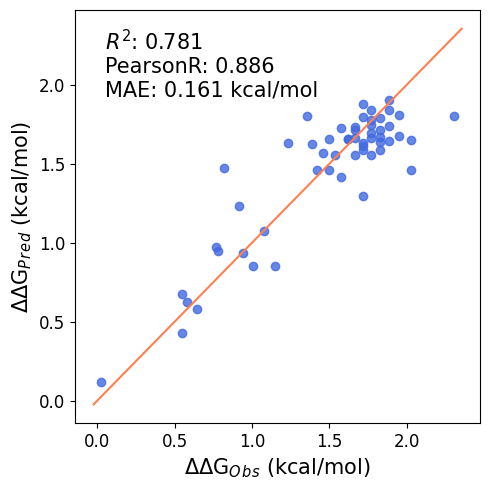

In [5]:
label_fontsize = 15
tick_fontsize = 12
plt.figure(figsize=(5, 5))
plt.scatter(va_Y, va_P, color='royalblue', alpha=0.8)
axis_min = min(float(np.min(va_Y)), float(np.min(va_P))) - 0.05
axis_max = max(float(np.max(va_Y)), float(np.max(va_P))) + 0.05
plt.plot([axis_min, axis_max], [axis_min, axis_max], color='coral')
plt.xlabel('ΔΔG$_O$$_b$$_s$ (kcal/mol)', fontsize=label_fontsize)
plt.ylabel('ΔΔG$_P$$_r$$_e$$_d$ (kcal/mol)', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.text(
    axis_min + 0.03 * (axis_max - axis_min),
    axis_max - 0.18 * (axis_max - axis_min),
    f'$R^2$: {r2:.3f}\nPearsonR: {pearson_r:.3f}\nMAE: {mae:.3f} kcal/mol',
    fontsize=15,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_model_loo_scatter.png', dpi=300)
plt.show()

## Fold-Averaged Feature Importance

For delta learning, each LOO split fits a base model on the selected ferrocene subset and a delta model on the 54 target-training reactions. The table below reports feature importance averaged across the 55 LOO fits.

In [6]:
base_importance_array = np.vstack(base_importances)
delta_importance_array = np.vstack(delta_importances)

importance_df = pd.DataFrame({
    'original_feature_index': selected_feature_indices,
    'feature_name': feature_names[selected_feature_indices],
    'feature_source': feature_sources[selected_feature_indices],
    'base_importance_mean': base_importance_array.mean(axis=0),
    'base_importance_std': base_importance_array.std(axis=0),
    'delta_importance_mean': delta_importance_array.mean(axis=0),
    'delta_importance_std': delta_importance_array.std(axis=0),
})
importance_df['component'] = importance_df['feature_name'].str.extract(r'^(Reactant1|Reactant2|Solvent|Reagent)')[0].fillna('TS')
importance_df['descriptor_name'] = importance_df['feature_name'].str.replace(r'^(Reactant1|Reactant2|Solvent|Reagent) SPOC ', '', regex=True)
importance_df['combined_importance'] = (
    importance_df['base_importance_mean'] + importance_df['delta_importance_mean']
) / 2
importance_df['combined_importance_norm'] = (
    importance_df['combined_importance'] / importance_df['combined_importance'].sum()
)
importance_df = importance_df.sort_values('combined_importance_norm', ascending=False).reset_index(drop=True)

out_csv = RESULTS_DIR / 'final_model_feature_importance.csv'
importance_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)
display(importance_df.head(30))

Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/scripts/results/final_model_feature_importance.csv


,original_feature_index,feature_name,feature_source,base_importance_mean,base_importance_std,delta_importance_mean,delta_importance_std,component,descriptor_name,combined_importance,combined_importance_norm
0,134,Reagent SPOC HallKierAlpha,SPOC,0.005864,0.002405,0.311680,0.103210,Reagent,HallKierAlpha,0.158772,0.158772
1,213,bv_11_r,TS,0.191786,0.086597,0.018062,0.024475,TS,bv_11_r,0.104924,0.104924
2,154,Reagent SPOC VSA_EState7,SPOC,0.011885,0.003651,0.111420,0.078581,Reagent,VSA_EState7,0.061653,0.061653
3,135,Reagent SPOC Kappa1,SPOC,0.025407,0.009706,0.079079,0.083935,Reagent,Kappa1,0.052243,0.052243
4,129,Reagent SPOC FpDensityMorgan1,SPOC,0.098683,0.028415,0.004918,0.006310,Reagent,FpDensityMorgan1,0.051800,0.051800
5,142,Reagent SPOC SMR_VSA10,SPOC,0.004470,0.004107,0.080687,0.064295,Reagent,SMR_VSA10,0.042579,0.042579
6,226,f+_11_s,TS,0.070189,0.101765,0.000546,0.001487,TS,f+_11_s,0.035367,0.035367
7,127,Reagent SPOC MolWt,SPOC,0.004991,0.002662,0.048810,0.020579,Reagent,MolWt,0.026901,0.026901
8,145,Reagent SPOC SMR_VSA5,SPOC,0.050493,0.009653,0.002678,0.004533,Reagent,SMR_VSA5,0.026585,0.026585
9,160,Reagent SPOC NumHAcceptors,SPOC,0.007571,0.007033,0.034423,0.031681,Reagent,NumHAcceptors,0.020997,0.020997


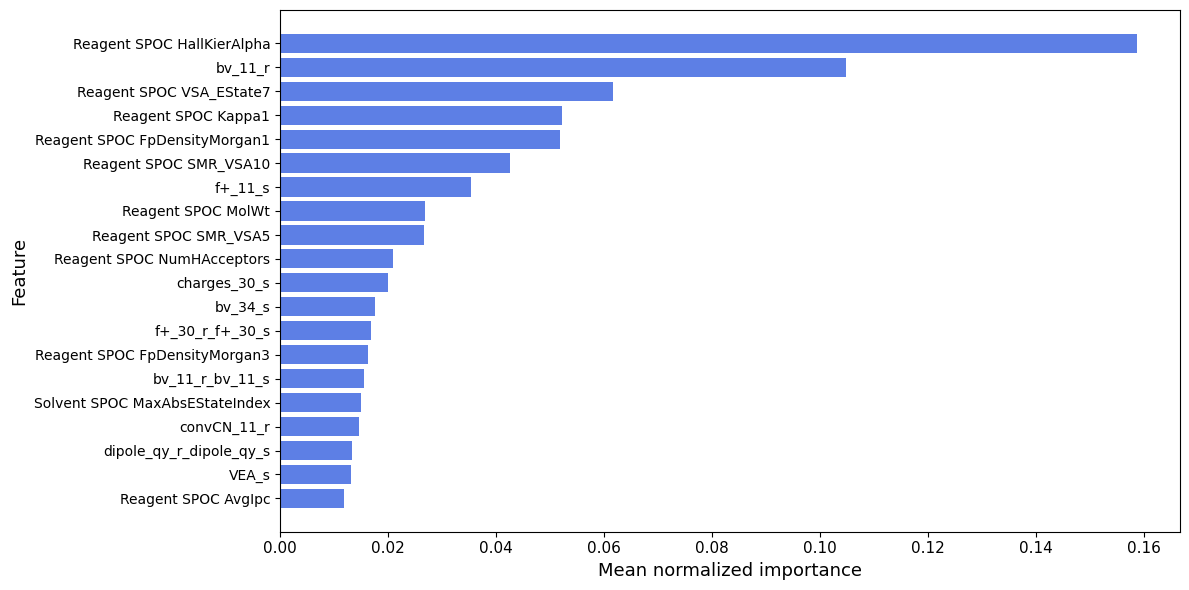

In [7]:
TOP_N = 20
plot_df = importance_df.head(TOP_N).iloc[::-1]

plt.figure(figsize=(12, max(4, 0.3 * TOP_N)))
plt.barh(plot_df['feature_name'], plot_df['combined_importance_norm'], color='royalblue', alpha=0.85)
plt.xlabel('Mean normalized importance', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_model_feature_importance_top20.png', dpi=300)
plt.show()